In [1]:
!pip install optuna
import os
import glob
import time
import json
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Advanced Models
import optuna
from sklearn.ensemble import RandomForestClassifier # <--- CHANGED: Use Random Forest
import shap

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import warnings
warnings.filterwarnings('ignore')

class Config:
    DATA_DIR = "/content/"
    MODEL_DIR = "/content/" # <--- CHANGED: Path

    # [0, 60...]
    HORIZONS = [0]

    FEATURE_COLS = [
        'rain', 'soil', 'temp', 'geo', 'humi',
        'rain_ema_60min','soil_ema_720min','geo_ema_8min'
    ]

    LABEL_COL = 'label'
    LABEL_MAP = {'normal': 0, 'warning': 1, 'critical': 2}

    # --- IMBALANCE HANDLING ---
    TARGET_SAMPLES = 10000

    # --- OPTIMIZATION ---
    OPTUNA_TRIALS = 100

    # RF Fixed Parameters
    RF_FIXED = {
        'n_jobs': -1,       # ใช้ทุก CPU
        'random_state': 42,
        'class_weight': None # เรา Balance ข้อมูลเองแล้ว
    }

cfg = Config()
if not os.path.exists(cfg.MODEL_DIR): os.makedirs(cfg.MODEL_DIR)
np.random.seed(42); random.seed(42)

def log(msg): print(f"[INFO] {time.strftime('%H:%M:%S')} - {msg}")
print("✅ Config Loaded (Random Forest Mode).")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 4.4 MB/s eta 0:00:00
✅ Config Loaded (Random Forest Mode).


In [2]:
def load_and_prep_data():
    log("Scanning & Loading All Data...")
    files = glob.glob(os.path.join(cfg.DATA_DIR, "*.csv"))
    if not files: files = glob.glob(os.path.join(cfg.DATA_DIR, "**/*.csv"), recursive=True)

    dfs = []
    for f in files:
        try:
            df = pd.read_csv(f)
            df.columns = [str(c).lower().strip().replace('.1', '') for c in df.columns]

            rename_map = {
                'temperature':'temp', 'hum':'humi', 'humidity':'humi',
                'devid':'devID', 'time':'timestamp', 'date':'timestamp'
            }
            new_cols = {c: rename_map[c] for c in df.columns if c in rename_map}
            if new_cols: df = df.rename(columns=new_cols)

            dfs.append(df)
            print(f"   + Loaded: {os.path.basename(f)} | Rows: {len(df)}")
        except Exception as e:
            print(f"   ! Error loading {f}: {e}")

    if not dfs: return None

    full_df = pd.concat(dfs, ignore_index=True)

    # Clean & Sort
    if 'timestamp' in full_df.columns:
        full_df['timestamp'] = pd.to_datetime(full_df['timestamp'], errors='coerce')
        full_df = full_df.dropna(subset=['timestamp'])

    if 'devID' in full_df.columns and 'timestamp' in full_df.columns:
        full_df = full_df.sort_values(by=['devID', 'timestamp'], ascending=[True, True])

    # -----------------------------------------------------------
    # STEP 1: LABEL HANDLING
    # -----------------------------------------------------------
    log("Processing Labels...")
    if cfg.LABEL_COL in full_df.columns:
        # A. เติม Null เป็น 'normal' ทันที
        full_df[cfg.LABEL_COL] = full_df[cfg.LABEL_COL].fillna('normal')

        # B. แปลงเป็น String และ clean
        full_df[cfg.LABEL_COL] = full_df[cfg.LABEL_COL].astype(str).str.lower().str.strip()

        # C. จัดการ Text แปลกๆ
        full_df.loc[full_df[cfg.LABEL_COL] == '', cfg.LABEL_COL] = 'normal'
        full_df.loc[full_df[cfg.LABEL_COL] == 'nan', cfg.LABEL_COL] = 'normal'

        # D. Map เป็นตัวเลข
        full_df[cfg.LABEL_COL] = full_df[cfg.LABEL_COL].map(cfg.LABEL_MAP).fillna(0).astype(int)
    else:
        full_df[cfg.LABEL_COL] = 0

    # -----------------------------------------------------------
    # STEP 2: SENSOR IMPUTATION
    # -----------------------------------------------------------
    log("Imputing Sensors (Forward & Backward Fill)...")

    cols_to_fill = [c for c in full_df.columns if c not in ['devID', 'timestamp', cfg.LABEL_COL]]

    if 'devID' in full_df.columns:
        full_df[cols_to_fill] = full_df.groupby('devID')[cols_to_fill].ffill()
        full_df[cols_to_fill] = full_df.groupby('devID')[cols_to_fill].bfill()

    full_df = full_df.fillna(0)

    return full_df.reset_index(drop=True)

# %%
# ====================================================================
# 3. STRATIFIED SPLIT
# ====================================================================
def prepare_data_pipeline(df, feature_cols, horizon=0):
    log(f"Preparing Data Pipeline (Horizon: {horizon})...")
    df_work = df.copy()

    # 1. Create Target
    if horizon > 0:
        df_work['target'] = df_work.groupby('devID')[cfg.LABEL_COL].shift(-horizon)
    else:
        df_work['target'] = df_work[cfg.LABEL_COL]

    df_work = df_work.dropna(subset=['target'])

    # 2. STRATIFIED SPLIT
    valid_feats = [c for c in feature_cols if c in df_work.columns]
    X = df_work[valid_feats].values
    y = df_work['target'].astype(int).values

    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.10, stratify=y, random_state=42
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.11111, stratify=y_temp, random_state=42
    )

    print(f"\n📊 --- Stratified Split Stats (Horizon +{horizon}) ---")
    def print_count(name, y_data):
        c = Counter(y_data)
        print(f"   📌 {name:10s} | Rows: {len(y_data):<6} | 0: {c[0]:<5} 1: {c[1]:<5} 2: {c[2]:<5}")

    print_count("TRAIN", y_train)
    print_count("VAL", y_val)
    print_count("TEST", y_test)

    return X_train, y_train, X_val, y_val, X_test, y_test

def balance_training_data(X_train, y_train):
    log("Applying Balancing to TRAIN set...")
    X_bal, y_bal = [], []
    for cls in np.unique(y_train):
        indices = np.where(y_train == cls)[0]
        count = len(indices)
        target = cfg.TARGET_SAMPLES
        if count == 0: continue

        if cls == 0 and count > target:
             chosen = np.random.choice(indices, target, replace=False)
        elif count < target:
             chosen = np.random.choice(indices, target, replace=True)
        else:
             chosen = indices

        X_bal.append(X_train[chosen])
        y_bal.append(y_train[chosen])

    X_bal = np.concatenate(X_bal)
    y_bal = np.concatenate(y_bal)

    perm = np.random.permutation(len(X_bal))
    return X_bal[perm], y_bal[perm]


In [3]:
def evaluate_set(y_true, y_pred, title):
    print(f"\n{'='*20} {title} {'='*20}")
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Warning', 'Critical'], zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Warning', 'Critical'],
                yticklabels=['Normal', 'Warning', 'Critical'])
    plt.title(f"Confusion Matrix: {title}")
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.show()

def plot_feature_importance(model, feature_names):
    # RF has native feature importance
    try:
        importance = model.feature_importances_
        fi_df = pd.DataFrame({'feature': feature_names, 'importance': importance})
        fi_df = fi_df.sort_values(by='importance', ascending=False).head(20)

        plt.figure(figsize=(10, 6))
        sns.barplot(x='importance', y='feature', data=fi_df, palette='viridis')
        plt.title('Top 20 Feature Importance (RF Native)')
        plt.tight_layout()
        plt.show()
    except: pass

def run_shap_analysis_rf(model, X_sample, feature_names, title_suffix=""):
    """
    SHAP for Random Forest: Uses TreeExplainer (Fast & Accurate)
    """
    print(f"\n🧠 Running SHAP Analysis for RF ({title_suffix})...")
    X_df = pd.DataFrame(X_sample, columns=feature_names)

    # TreeExplainer รองรับ Random Forest (ใช้ model ไม่ต้องใช้ predict_proba)
    explainer = shap.TreeExplainer(model)

    # คำนวณ SHAP values (multiclass จะได้ list)
    # check_additivity=False เพื่อป้องกัน error เรื่อง precision เล็กน้อยใน RF
    shap_values = explainer.shap_values(X_df, check_additivity=False)

    # Plot 1: Summary Bar
    print("   👉 SHAP Summary Plot")
    plt.figure()
    shap.summary_plot(shap_values, X_df, plot_type="bar", show=False)
    plt.title(f"SHAP Global Importance - {title_suffix}")
    plt.show()

    # Plot 2: Beeswarm for Critical Class
    if isinstance(shap_values, list) and len(shap_values) > 2:
        print("   👉 SHAP Beeswarm Plot (Critical Class)")
        plt.figure()
        shap.summary_plot(shap_values[2], X_df, show=False)
        plt.title(f"SHAP Values (Critical Class) - {title_suffix}")
        plt.show()

# ====================================================================
# 5. OPTIMIZATION (Random Forest)
# ====================================================================
def objective(trial, X_tr, y_tr, X_val, y_val):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100,200),
        'max_depth': trial.suggest_int('max_depth', 10,20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2,6),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1,5),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    }

    model = RandomForestClassifier(**params, **cfg.RF_FIXED)
    model.fit(X_tr, y_tr)

    preds = model.predict(X_val)
    return f1_score(y_val, preds, average='macro', zero_division=0)


[INFO] 07:17:04 - Scanning & Loading All Data...
   + Loaded: campus_data_ema_pre_optimized.csv | Rows: 301191
[INFO] 07:17:33 - Processing Labels...
[INFO] 07:17:33 - Imputing Sensors (Forward & Backward Fill)...
👉 Features Used: 8

🚀 HORIZON: +0 Steps
[INFO] 07:17:34 - Preparing Data Pipeline (Horizon: 0)...

📊 --- Stratified Split Stats (Horizon +0) ---
   📌 TRAIN      | Rows: 95824  | 0: 94607 1: 1158  2: 59   
   📌 VAL        | Rows: 11978  | 0: 11826 1: 145   2: 7    
   📌 TEST       | Rows: 11978  | 0: 11826 1: 145   2: 7    
[INFO] 07:17:34 - Applying Balancing to TRAIN set...
[INFO] 07:17:34 - Tuning Hyperparameters (RF)...
   🏆 Best Params: {'n_estimators': 137, 'max_depth': 14, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2'}
[INFO] 07:21:41 - Training Final RF Model...

🔎 Evaluating TRAIN Set (Balanced)...

==================== TRAIN - H0 ====================
              precision    recall  f1-score   support

      Normal       1.00      1.00      

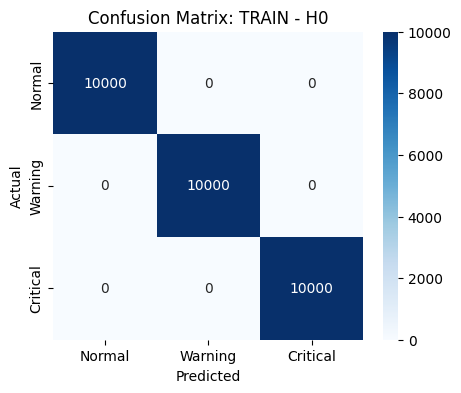


🔎 Evaluating VALIDATION Set...

==================== VAL - H0 ====================
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     11826
     Warning       0.97      1.00      0.98       145
    Critical       1.00      1.00      1.00         7

    accuracy                           1.00     11978
   macro avg       0.99      1.00      0.99     11978
weighted avg       1.00      1.00      1.00     11978



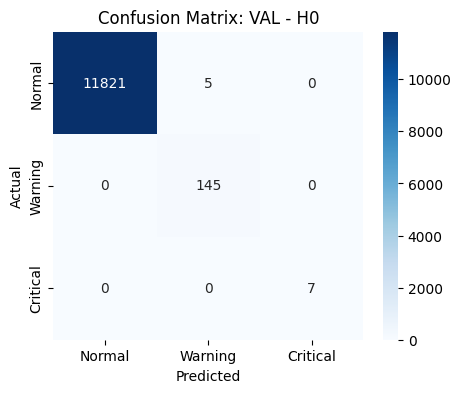


🔎 Evaluating TEST Set...

==================== TEST - H0 ====================
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     11826
     Warning       0.95      1.00      0.98       145
    Critical       1.00      0.86      0.92         7

    accuracy                           1.00     11978
   macro avg       0.98      0.95      0.97     11978
weighted avg       1.00      1.00      1.00     11978



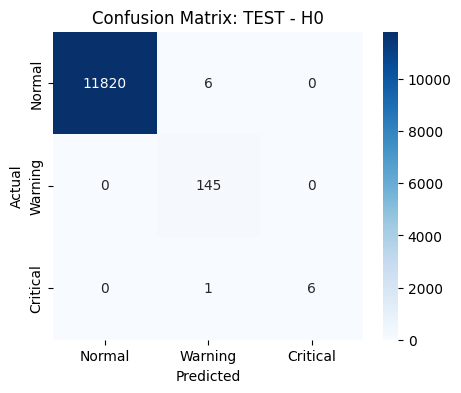

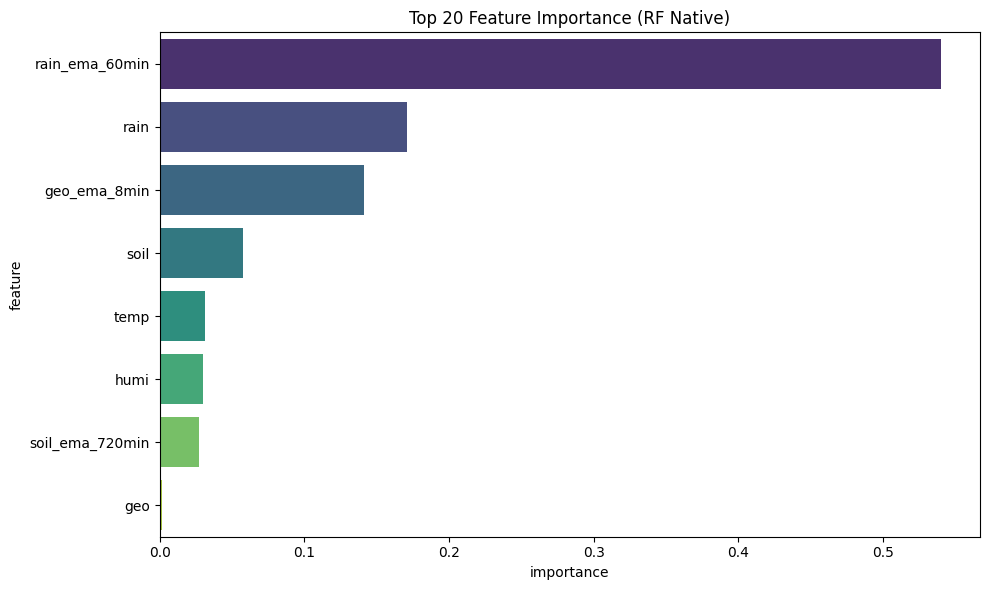


🧠 Running SHAP Analysis for RF (H0)...
   👉 SHAP Summary Plot


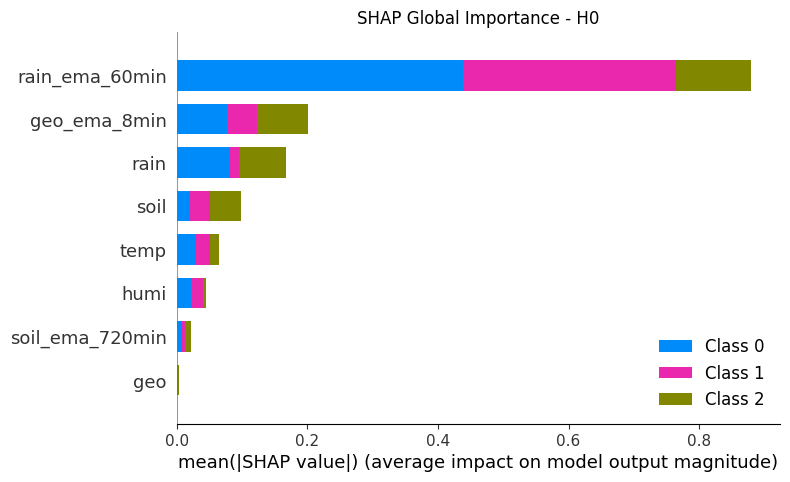


✅ Process Completed.


In [4]:
# 6. MAIN EXECUTION
# ====================================================================
def main():
    # 1. Load Data
    df_raw = load_and_prep_data()
    if df_raw is None: return

    if not cfg.FEATURE_COLS:
        cfg.FEATURE_COLS = [c for c in df_raw.columns if c not in [cfg.LABEL_COL, 'timestamp', 'devID', 'target', 'is_test']]
    print(f"👉 Features Used: {len(cfg.FEATURE_COLS)}")

    for h in cfg.HORIZONS:
        print(f"\n{'='*50}\n🚀 HORIZON: +{h} Steps\n{'='*50}")

        # 2. Split
        X_train_raw, y_train, X_val_raw, y_val, X_test_raw, y_test = prepare_data_pipeline(df_raw, cfg.FEATURE_COLS, h)
        if len(X_train_raw) == 0: continue

        # 3. Scale (RF ไม่จำเป็นต้อง Scale มากนัก แต่ทำไว้เพื่อให้ Pipeline เหมือนกับ model อื่น)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_raw)
        X_val_scaled = scaler.transform(X_val_raw)
        X_test_scaled = scaler.transform(X_test_raw)

        joblib.dump(scaler, f"{cfg.MODEL_DIR}/scaler_h{h}.save")

        # 4. Balance
        X_train_bal, y_train_bal = balance_training_data(X_train_scaled, y_train)

        # 5. Optimize
        log(f"Tuning Hyperparameters (RF)...")
        optuna.logging.set_verbosity(optuna.logging.WARNING)
        study = optuna.create_study(direction='maximize')

        study.optimize(lambda t: objective(t, X_train_bal, y_train_bal, X_val_scaled, y_val), n_trials=cfg.OPTUNA_TRIALS)

        best_params = study.best_params
        print(f"   🏆 Best Params: {best_params}")

        # 6. Final Train
        log("Training Final RF Model...")
        final_model = RandomForestClassifier(**best_params, **cfg.RF_FIXED)
        final_model.fit(X_train_bal, y_train_bal)

        # Save Model
        joblib.dump(final_model, os.path.join(cfg.MODEL_DIR, f"rf_strat_h{h}.pkl"))

        # 7. Evaluate
        print("\n🔎 Evaluating TRAIN Set (Balanced)...")
        evaluate_set(y_train_bal, final_model.predict(X_train_bal), f"TRAIN - H{h}")

        print("\n🔎 Evaluating VALIDATION Set...")
        evaluate_set(y_val, final_model.predict(X_val_scaled), f"VAL - H{h}")

        print("\n🔎 Evaluating TEST Set...")
        evaluate_set(y_test, final_model.predict(X_test_scaled), f"TEST - H{h}")

        # 8. Feature Importance (Native)
        plot_feature_importance(final_model, cfg.FEATURE_COLS)

        # 9. SHAP (TreeExplainer is fast, can use more samples)
        shap_sample_size = min(500, len(X_test_scaled)) # 500 is safe for TreeExplainer
        if shap_sample_size > 0:
            idx = np.random.choice(len(X_test_scaled), shap_sample_size, replace=False)
            run_shap_analysis_rf(final_model, X_test_scaled[idx], cfg.FEATURE_COLS, title_suffix=f"H{h}")

    print("\n✅ Process Completed.")

if __name__ == "__main__":
    main()

In [5]:
df_raw = load_and_prep_data()

if not cfg.FEATURE_COLS:
    cfg.FEATURE_COLS = [c for c in df_raw.columns if c not in [cfg.LABEL_COL, 'timestamp', 'devID', 'target', 'is_test']]

# Assuming horizon 0 as it was used in the previous run.
X_train_raw, y_train, X_val_raw, y_val, X_test_raw, y_test = prepare_data_pipeline(df_raw, cfg.FEATURE_COLS, horizon=0)

# Create a DataFrame for the test features
test_df = pd.DataFrame(X_test_raw, columns=cfg.FEATURE_COLS)

# Add the true labels to the test DataFrame
test_df['label'] = y_test

log("Test DataFrame created. Displaying the first 5 rows:")
display(test_df.head())

[INFO] 07:21:45 - Scanning & Loading All Data...
   + Loaded: campus_data_ema_pre_optimized.csv | Rows: 301191
[INFO] 07:22:14 - Processing Labels...
[INFO] 07:22:15 - Imputing Sensors (Forward & Backward Fill)...
[INFO] 07:22:15 - Preparing Data Pipeline (Horizon: 0)...

📊 --- Stratified Split Stats (Horizon +0) ---
   📌 TRAIN      | Rows: 95824  | 0: 94607 1: 1158  2: 59   
   📌 VAL        | Rows: 11978  | 0: 11826 1: 145   2: 7    
   📌 TEST       | Rows: 11978  | 0: 11826 1: 145   2: 7    
[INFO] 07:22:16 - Test DataFrame created. Displaying the first 5 rows:


,rain,soil,temp,geo,humi,rain_ema_60min,soil_ema_720min,geo_ema_8min,label
0,0.0,49.099998,31.585030,3.170694,68.095901,2.064230e-04,49.873743,4.780378,0
1,0.0,61.700001,26.802471,2.696178,83.934769,1.431300e-04,61.952181,3.842173,0
2,0.0,41.099998,27.753109,11.304137,84.756851,7.580000e-10,43.438053,13.272824,0
3,0.0,56.400002,27.606239,3.905784,80.846725,3.055255e-01,52.597356,4.156039,0
4,0.0,51.700001,27.424660,0.873602,80.629280,4.774191e-02,51.722467,12.474939,0
